In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns 

iris = sns.load_dataset("iris")

In [3]:
species_int = []
for r in iris.values:
    match r[4]:
        case 'setosa':
            species_int.append(1)
        case 'versicolor':
            species_int.append(2)
        case 'virginica':
            species_int.append(3)

C:\Users\Ксюша\AppData\Local\Temp\ipykernel_20156\1579674482.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['species'] = species_int_df


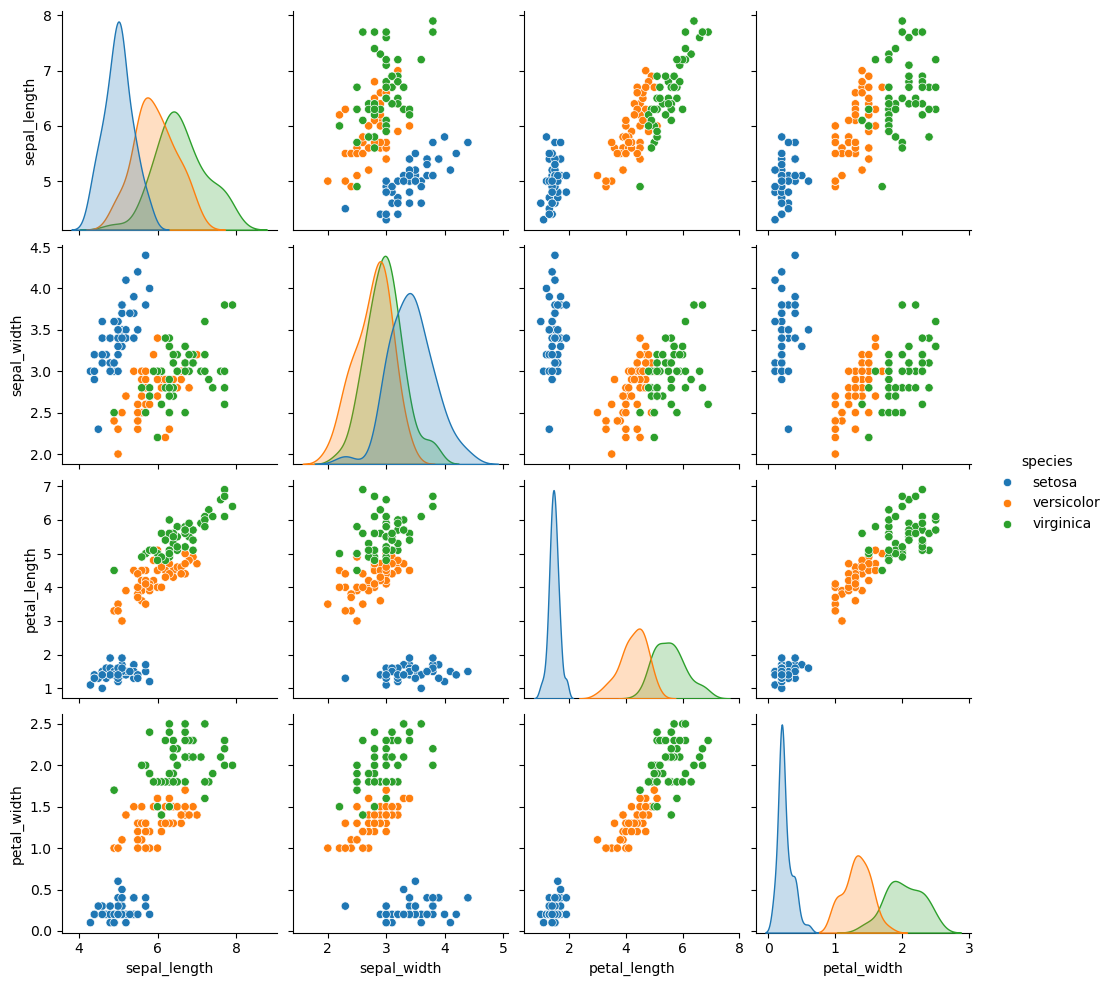

In [9]:
species_int_df = pd.DataFrame(species_int)
data = iris[["sepal_length", "petal_length"]]
data['species'] = species_int_df
sns.pairplot(iris, hue='species')
plt.show()

In [11]:
data_setosa = data[data['species'] == 1]
data_versicolor = data[data['species'] == 2]
data_verginica = data[data['species'] == 3]
print(data_versicolor.shape)

(50, 3)


In [13]:
data_versicolor_A = data_versicolor.iloc[:25, :]
data_versicolor_B = data_versicolor.iloc[25:, :]

data_verginica_A = data_verginica.iloc[:25, :]
data_verginica_B = data_verginica.iloc[25:, :]

print(data_versicolor_A.shape)
print(data_versicolor_B.shape)

print(data_verginica_A.shape)
print(data_verginica_B.shape)

(25, 3)
(25, 3)
(25, 3)
(25, 3)


In [15]:
data_df_A = pd.concat([data_verginica_A, data_versicolor_A], ignore_index=True)
data_df_B = pd.concat([data_verginica_B, data_versicolor_B], ignore_index=True)

print(data_df_A)
print(data_df_B)

    sepal_length  petal_length  species
0            6.3           6.0        3
1            5.8           5.1        3
2            7.1           5.9        3
3            6.3           5.6        3
4            6.5           5.8        3
5            7.6           6.6        3
6            4.9           4.5        3
7            7.3           6.3        3
8            6.7           5.8        3
9            7.2           6.1        3
10           6.5           5.1        3
11           6.4           5.3        3
12           6.8           5.5        3
13           5.7           5.0        3
14           5.8           5.1        3
15           6.4           5.3        3
16           6.5           5.5        3
17           7.7           6.7        3
18           7.7           6.9        3
19           6.0           5.0        3
20           6.9           5.7        3
21           5.6           4.9        3
22           7.7           6.7        3
23           6.3           4.9        3


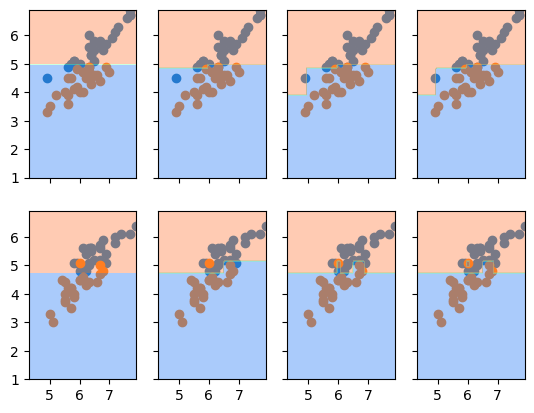

In [17]:
from sklearn.tree import DecisionTreeClassifier
fig, ax = plt.subplots(2, 4, sharex='col', sharey='row')
max_depth = [1, 3, 5, 7]
X = data_df_A[['sepal_length', 'petal_length']]
y = data_df_A['species']

x1_p = np.linspace(min(data["sepal_length"]), max(data["sepal_length"]), 100)
x2_p = np.linspace(min(data["petal_length"]), max(data["petal_length"]), 100)
X1_p, X2_p = np.meshgrid(x1_p, x2_p)

X_p = pd.DataFrame(np.vstack([X1_p.ravel(), X2_p.ravel()]).T, columns=["sepal_length", "petal_length"])

j = 0
for md in max_depth:
    model = DecisionTreeClassifier(max_depth=md)
    model.fit(X, y)
    ax[0, j].scatter(data_verginica_A['sepal_length'], data_verginica_A['petal_length'])
    ax[0, j].scatter(data_versicolor_A['sepal_length'], data_versicolor_A['petal_length'])
    y_p = model.predict(X_p)
    ax[0, j].contourf(X1_p, X2_p, y_p.reshape(X1_p.shape), alpha=0.4, levels=2, cmap='rainbow', zorder=1)
    j+=1


X = data_df_B[['sepal_length', 'petal_length']]
y = data_df_B['species']
j = 0
for md in max_depth:
    model = DecisionTreeClassifier(max_depth=md)
    model.fit(X, y)
    ax[1, j].scatter(data_verginica_B['sepal_length'], data_verginica_B['petal_length'])
    ax[1, j].scatter(data_versicolor_B['sepal_length'], data_versicolor_B['petal_length'])
    y_p = model.predict(X_p)
    ax[1, j].contourf(X1_p, X2_p, y_p.reshape(X1_p.shape), alpha=0.4, levels=2, cmap='rainbow', zorder=1)
    j+=1

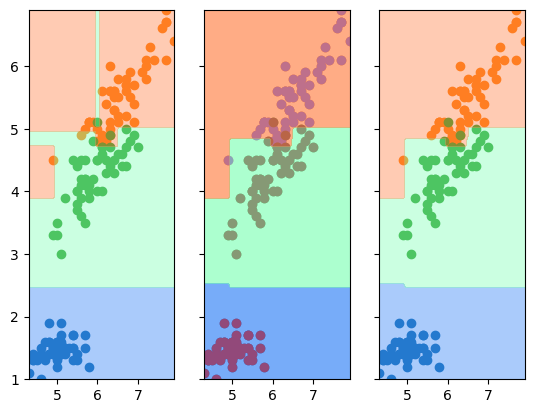

In [19]:
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier

# ансамблевые методы. идея объединения нескольких переобученных моделей - баггинг
fig, ax = plt.subplots(1, 3, sharex='col', sharey='row')

ax[0].scatter(data_setosa['sepal_length'], data_setosa['petal_length'])
ax[0].scatter(data_verginica['sepal_length'], data_verginica['petal_length'])
ax[0].scatter(data_versicolor['sepal_length'], data_versicolor['petal_length'])

X = data[['sepal_length', 'petal_length']]
y = data['species']

model1 = DecisionTreeClassifier(max_depth=6)
model1.fit(X, y)
y_p1 = model1.predict(X_p)
ax[0].contourf(X1_p, X2_p, y_p1.reshape(X1_p.shape), alpha=0.4, levels=2, cmap='rainbow', zorder=1)


model2 = DecisionTreeClassifier(max_depth=6)
b = BaggingClassifier(model2, n_estimators=20, max_samples=0.8, random_state=1)
b.fit(X, y)


y_p2 = b.predict(X_p)
ax[1].scatter(data_setosa['sepal_length'], data_setosa['petal_length'])
ax[1].scatter(data_verginica['sepal_length'], data_verginica['petal_length'])
ax[1].scatter(data_versicolor['sepal_length'], data_versicolor['petal_length'])
ax[1].contourf(X1_p, X2_p, y_p2.reshape(X1_p.shape), alpha=0.4, levels=2, cmap='rainbow', zorder=1)


model2 = DecisionTreeClassifier(max_depth=6)
b = BaggingClassifier(model2, n_estimators=20, max_samples=0.8, random_state=1)
b.fit(X, y)


y_p2 = b.predict(X_p)
ax[1].scatter(data_setosa['sepal_length'], data_setosa['petal_length'])
ax[1].scatter(data_verginica['sepal_length'], data_verginica['petal_length'])
ax[1].scatter(data_versicolor['sepal_length'], data_versicolor['petal_length'])
ax[1].contourf(X1_p, X2_p, y_p2.reshape(X1_p.shape), alpha=0.4, levels=2, cmap='rainbow', zorder=1)

model3 = RandomForestClassifier(n_estimators=2, max_samples=0.5, random_state=1)
model3.fit(X, y)


y_p3 = b.predict(X_p)
ax[2].scatter(data_setosa['sepal_length'], data_setosa['petal_length'])
ax[2].scatter(data_verginica['sepal_length'], data_verginica['petal_length'])
ax[2].scatter(data_versicolor['sepal_length'], data_versicolor['petal_length'])
ax[2].contourf(X1_p, X2_p, y_p3.reshape(X1_p.shape), alpha=0.4, levels=2, cmap='rainbow', zorder=1)

C:\Users\Public\anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


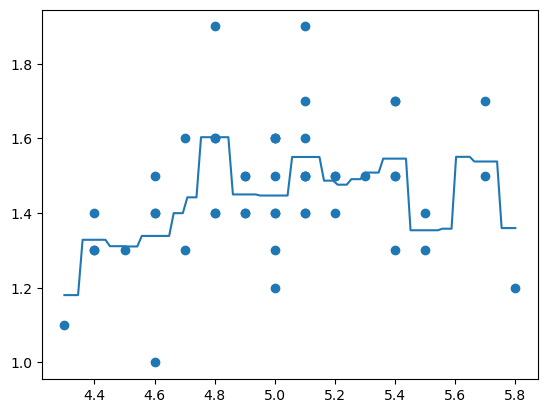

In [21]:
# регрессия с помощью случайных лесов
iris = sns.load_dataset('iris')
data = iris[["sepal_length", "petal_length", 'species']]

data_setosa = data[data['species'] == 'setosa']
x_p = pd.DataFrame(np.linspace(min(data_setosa["sepal_length"]), max(data_setosa["sepal_length"]), 100))

X = pd.DataFrame(data_setosa['sepal_length'], columns=['sepal_length'])

y = data_setosa['petal_length']

from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=20)
model.fit(X, y)

y_p = model.predict(x_p)
plt.scatter(data_setosa['sepal_length'], data_setosa['petal_length'])
plt.plot(x_p, y_p)

[[-0.33232711 -0.94316419]
 [ 0.94316419 -0.33232711]]
[0.24657408 0.01334837]
[1.326 4.26 ]


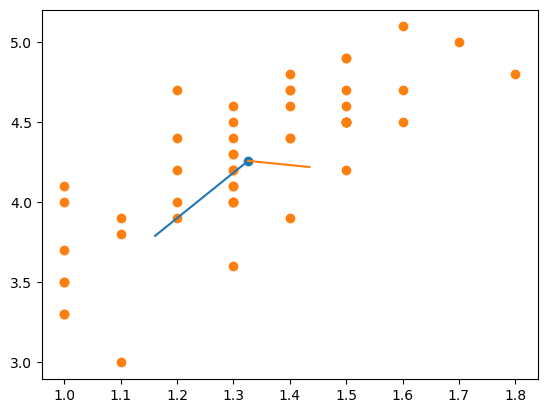

In [23]:
# метод главных компонент PCA - без учителя, используют для понижения размерности

iris = sns.load_dataset('iris')
data = iris[["petal_width", "petal_length", 'species']]
data_v = data[data['species'] == 'versicolor']
data_v = data_v.drop(columns=['species'])
X = data_v['petal_width']
Y = data_v['petal_length']

from sklearn.decomposition import PCA
p = PCA(n_components=2)

p.fit(data_v)
X_p = p.transform(data_v)

print(p.components_)
print(p.explained_variance_)
print(p.mean_)
plt.scatter(p.mean_[0], p.mean_[1])
plt.scatter(X, Y)
plt.plot([p.mean_[0], p.mean_[0] + p.components_[0][0] * np.sqrt(p.explained_variance_[0])],
         [p.mean_[1], p.mean_[1] + p.components_[0][1] * np.sqrt(p.explained_variance_[0])],)

plt.plot([p.mean_[0], p.mean_[0] + p.components_[1][0] * np.sqrt(p.explained_variance_[1])],
         [p.mean_[1], p.mean_[1] + p.components_[1][1] * np.sqrt(p.explained_variance_[1])],)

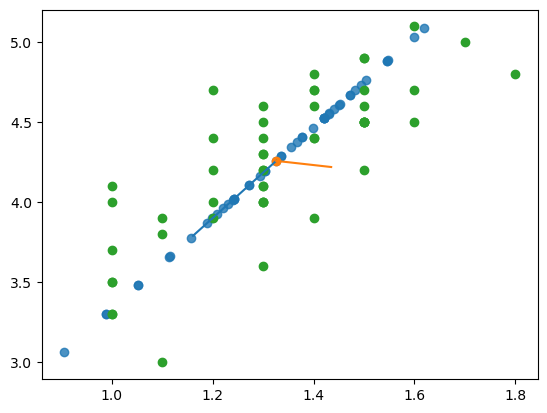

In [25]:
p1 = PCA(n_components=1)

p1.fit(data_v)
X_p = p1.transform(data_v)
X_p_new = p1.inverse_transform(X_p)
#print(X_p_new)
plt.scatter(X_p_new[:, 0], X_p_new[:, 1], alpha=0.8)
plt.scatter(p.mean_[0], p.mean_[1])
plt.scatter(X, Y)
plt.plot([p.mean_[0], p.mean_[0] + p.components_[0][0] * np.sqrt(p.explained_variance_[0])],
         [p.mean_[1], p.mean_[1] + p.components_[0][1] * np.sqrt(p.explained_variance_[0])],)

plt.plot([p.mean_[0], p.mean_[0] + p.components_[1][0] * np.sqrt(p.explained_variance_[1])],
         [p.mean_[1], p.mean_[1] + p.components_[1][1] * np.sqrt(p.explained_variance_[1])],)